# Analysis of teams

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json
import ast
import warnings
from datetime import datetime

In [67]:
df = pd.read_csv('data2.csv')
print(df.head())

                Team ID Team Name               contactEmail  \
0  0xZ6Wl110SbbldBH4zXH   4 gacon        decomchay@gmail.com   
1  20ZXmM80SMyT0noOzCsZ    a8-hbt  tunglamnguyenxd@gmail.com   
2  2T4ZvCdUxqRfCgkq20YE  Gugugaga        ngoctabao@gmail.com   
3  2nqAYdRZjGd9uDZSwxGD        3P        tvu716714@gmail.com   
4  3t1BKi6tXuov5SrD5BNe  TOMATOAI     legiavan0210@gmail.com   

                                         institution  \
0  Đại học Giao Thông Vận Tải Thành Phố Hồ Chí Mi...   
1  Đại học Công nghệ Thông tin và Truyền thông Vi...   
2                                     FPT University   
3                           Đại học Bách Khoa Hà Nội   
4        Trường Đại Học Kinh Tế - Luật (ĐHQG TP.HCM)   

                                             members  \
0  [{"major":"Khoa Học Dữ Liệu","university":"Gia...   
1  [{"major":"Khoa học Máy tính","email":"tunglam...   
2  [{"major":"Trí tuệ nhân tạo","university":"FPT...   
3  [{"memberName":"Vũ Đỗ Minh Thảo","dob":"2006-0...  

In [68]:
df['institution'].nunique()

95

In [69]:
df['members'].head()

0    [{"major":"Khoa Học Dữ Liệu","university":"Gia...
1    [{"major":"Khoa học Máy tính","email":"tunglam...
2    [{"major":"Trí tuệ nhân tạo","university":"FPT...
3    [{"memberName":"Vũ Đỗ Minh Thảo","dob":"2006-0...
4    [{"major":"Kinh doanh số và Trí tuệ nhân tạo",...
Name: members, dtype: object

In [70]:
warnings.filterwarnings('ignore')

# ── Styling ──────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = ['#4361EE', '#3A0CA3', '#7209B7', '#F72585', '#4CC9F0',
           '#4895EF', '#560BAD', '#B5179E', '#FF6B6B', '#48BFE3']
sns.set_palette(PALETTE)

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
})


In [71]:
# ── Parse registeredAt to datetime ────────────────────────────
def parse_registration_date(date_str):
    
    if pd.isna(date_str):
        return pd.NaT
    try:
        # Try the format: "March 23, 2026 at 7:27:24 PM UTC+7"
        clean = date_str.replace('\\xa0', ' ').strip()
        # Remove timezone info for parsing
        for tz in ['UTC+7', 'UTC+07', 'GMT+7', 'ICT']:
            clean = clean.replace(tz, '').strip()
        # Try multiple formats
        for fmt in [
            '%B %d, %Y at %I:%M:%S %p',
            '%B %d, %Y at %H:%M:%S',
            '%b %d, %Y at %I:%M:%S %p',
            '%Y-%m-%dT%H:%M:%S',
        ]:
            try:
                return pd.to_datetime(clean, format=fmt)
            except (ValueError, TypeError):
                continue
        return pd.to_datetime(clean)
    except Exception:
        return pd.NaT

df['registered_dt'] = df['registeredAt'].apply(parse_registration_date)
df['reg_date'] = df['registered_dt'].dt.date

print(f"Parsed {df['registered_dt'].notna().sum()} / {len(df)} registration dates.")
print(f"Date range: {df['registered_dt'].min()} → {df['registered_dt'].max()}")

Parsed 125 / 125 registration dates.
Date range: 2026-03-20 22:55:47 → 2026-03-27 09:38:43


In [72]:
# def parse_members(members_str):
  
#     if pd.isna(members_str):
#         return []
#     try:
#         return json.loads(members_str)
#     except (json.JSONDecodeError, TypeError):
#         try:
#             return ast.literal_eval(members_str)
#         except (ValueError, SyntaxError):
#             return []

# df['members_parsed'] = df['members'].apply(parse_members)
# df['team_size'] = df['members_parsed'].apply(len)

# # Flatten all members into a single DataFrame
# all_members = []
# for _, row in df.iterrows():
#     for m in row['members_parsed']:
#         m_copy = dict(m)
#         m_copy['team_id'] = row['Team ID']
#         m_copy['team_name'] = row['Team Name']
#         all_members.append(m_copy)

# members_df = pd.DataFrame(all_members)
# print(f"Total individual participants: {len(members_df)}")
# print(f"Member columns: {list(members_df.columns)}")
# if len(members_df) > 0:
#     members_df.head()

In [73]:
def parse_members(members_str):
    if pd.isna(members_str):
        return []
    try:
        return json.loads(members_str)
    except (json.JSONDecodeError, TypeError):
        try:
            return ast.literal_eval(members_str)
        except (ValueError, SyntaxError):
            return []

df['members_parsed'] = df['members'].apply(parse_members)
df['team_size'] = df['members_parsed'].apply(len)

# Flatten all members into a single DataFrame
all_members = []
for _, row in df.iterrows():
    for m in row['members_parsed']:
        m_copy = dict(m)
        m_copy['team_id'] = row['Team ID']
        m_copy['team_name'] = row['Team Name']
        all_members.append(m_copy)

members_df = pd.DataFrame(all_members)
print(f"Total individual participants: {len(members_df)}")
print(f"Member columns: {list(members_df.columns)}")
if len(members_df) > 0:
    members_df.head()

Total individual participants: 409
Member columns: ['major', 'university', 'email', 'phone', 'role', 'dob', 'memberName', 'team_id', 'team_name']


In [74]:
# total_teams = len(df)
# total_participants = len(members_df) if len(members_df) > 0 else df['team_size'].sum()
# unique_institutions = df['institution'].nunique()
# avg_team_size = df['team_size'].mean()

# # Detect submission column(s)
# submission_cols = [c for c in df.columns if 'submission' in c.lower() or 'Submission' in c]
# if submission_cols:
#     submitted = df[submission_cols[0]].notna().sum()
#     submission_rate = submitted / total_teams * 100
# else:
#     submitted = 'N/A'
#     submission_rate = 0

# # Detect status column
# status_col = None
# for c in df.columns:
#     if c.lower().strip() in ['status', 'state']:
#         status_col = c
#         break
# # Fallback: last column if unnamed or matches pattern
# if status_col is None:
#     last_col = df.columns[-1]
#     if df[last_col].dtype == 'object':
#         status_col = last_col

# print("=" * 52)
# print("         📊 DATATHON — KEY METRICS")
# print("=" * 52)
# print(f"  🏫 Institutions represented:  {unique_institutions}")
# print(f"  👥 Total teams registered:    {total_teams}")
# print(f"  🧑 Total participants:        {total_participants}")
# print(f"  📐 Average team size:         {avg_team_size:.1f}")
# if submitted != 'N/A':
#     print(f"  📝 Round 1 submissions:       {submitted} ({submission_rate:.1f}%)")
# print("=" * 52)

In [75]:
# ── Summary Statistics Card ───────────────────────────────────
total_teams = len(df)
total_participants = len(members_df) if len(members_df) > 0 else df['team_size'].sum()
avg_team_size = df['team_size'].mean()

# Institution counts at MEMBER level (since teams can span multiple universities)
if len(members_df) > 0 and 'university' in members_df.columns:
    inst_counts = members_df['university'].dropna().str.strip().value_counts()
    unique_institutions = members_df['university'].dropna().str.strip().nunique()
else:
    inst_counts = df['institution'].value_counts()
    unique_institutions = df['institution'].nunique()

# Detect submission column(s)
submission_cols = [c for c in df.columns if 'submission' in c.lower() or 'Submission' in c]
if submission_cols:
    submitted = df[submission_cols[0]].notna().sum()
    submission_rate = submitted / total_teams * 100
else:
    submitted = 'N/A'
    submission_rate = 0

# Detect status column
status_col = None
for c in df.columns:
    if c.lower().strip() in ['status', 'state']:
        status_col = c
        break
# Fallback: last column if unnamed or matches pattern
if status_col is None:
    last_col = df.columns[-1]
    if df[last_col].dtype == 'object':
        status_col = last_col

print("=" * 52)
print("         📊 DATATHON — KEY METRICS")
print("=" * 52)
print(f"  🏫 Institutions (member-level): {unique_institutions}")
print(f"  👥 Total teams registered:      {total_teams}")
print(f"  🧑 Total participants:          {total_participants}")
print(f"  📐 Average team size:           {avg_team_size:.1f}")
if submitted != 'N/A':
    print(f"  📝 Round 1 submissions:         {submitted} ({submission_rate:.1f}%)")
print("=" * 52)

         📊 DATATHON — KEY METRICS
  🏫 Institutions (member-level): 169
  👥 Total teams registered:      125
  🧑 Total participants:          409
  📐 Average team size:           3.3
  📝 Round 1 submissions:         0 (0.0%)


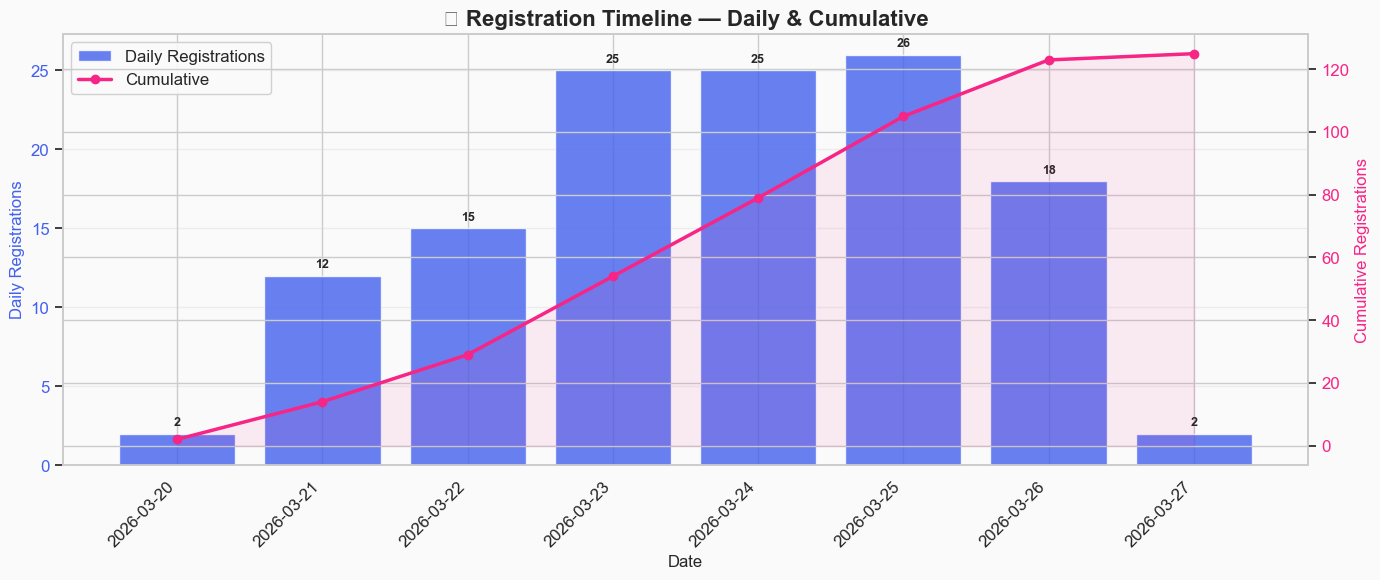

In [76]:
# ── Daily Registrations + Cumulative Line ─────────────────────
reg_by_date = df.groupby('reg_date').size().reset_index(name='count')
reg_by_date = reg_by_date.sort_values('reg_date')
reg_by_date['cumulative'] = reg_by_date['count'].cumsum()

fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart
bars = ax1.bar(range(len(reg_by_date)), reg_by_date['count'],
               color=PALETTE[0], alpha=0.8, label='Daily Registrations', zorder=3)
ax1.set_xlabel('Date')
ax1.set_ylabel('Daily Registrations', color=PALETTE[0])
ax1.tick_params(axis='y', labelcolor=PALETTE[0])

# Add value labels on bars
for bar in bars:
    h = bar.get_height()
    if h > 0:
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                 f'{int(h)}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Cumulative line on twin axis
ax2 = ax1.twinx()
ax2.plot(range(len(reg_by_date)), reg_by_date['cumulative'],
         color=PALETTE[3], linewidth=2.5, marker='o', markersize=6,
         label='Cumulative', zorder=4)
ax2.set_ylabel('Cumulative Registrations', color=PALETTE[3])
ax2.tick_params(axis='y', labelcolor=PALETTE[3])
ax2.fill_between(range(len(reg_by_date)), reg_by_date['cumulative'],
                 alpha=0.08, color=PALETTE[3])

# X-axis labels
ax1.set_xticks(range(len(reg_by_date)))
ax1.set_xticklabels([str(d) for d in reg_by_date['reg_date']], rotation=45, ha='right')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', framealpha=0.9)

ax1.set_title('📅 Registration Timeline — Daily & Cumulative')
ax1.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

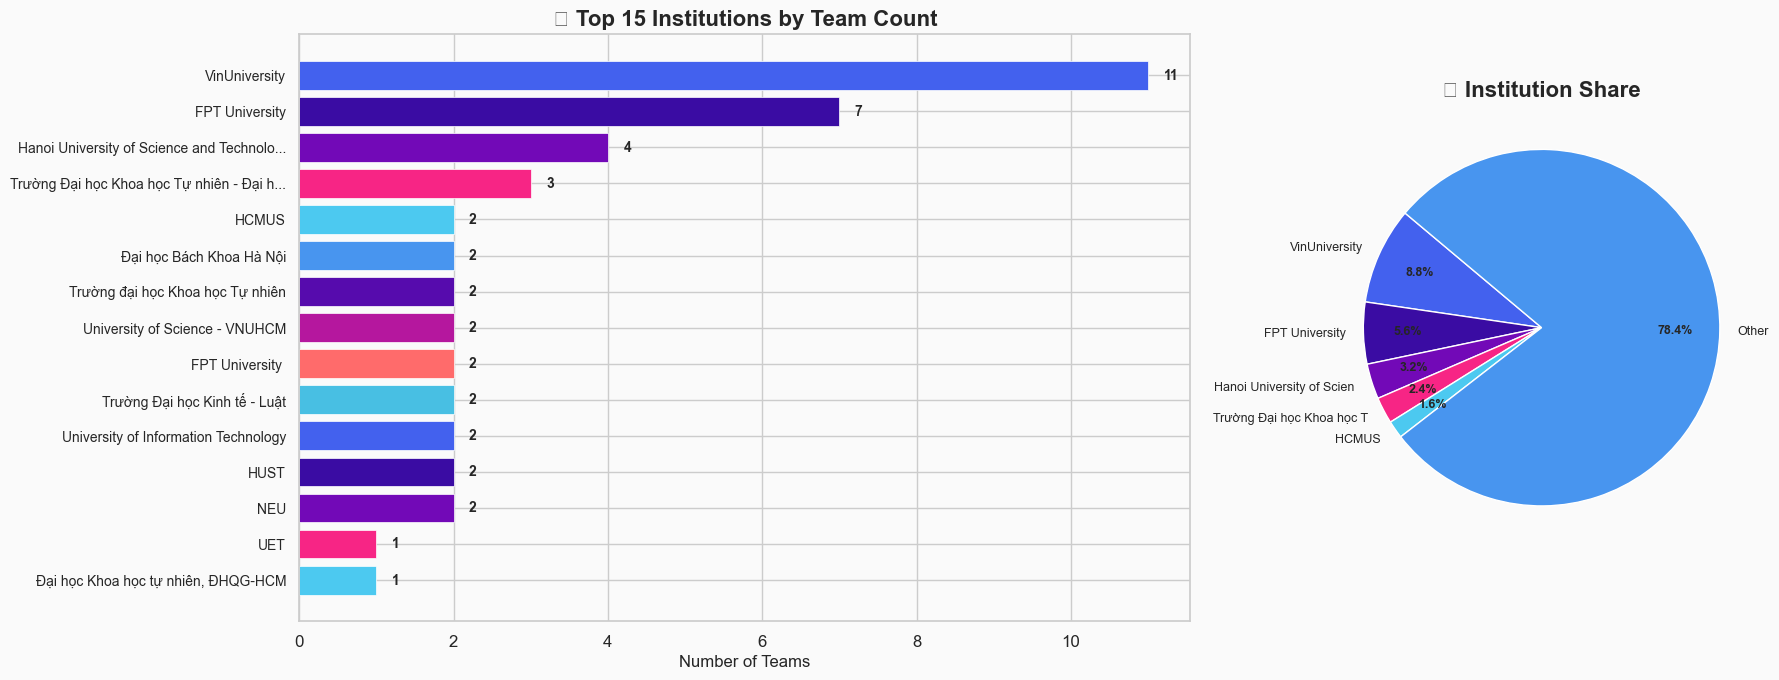

In [77]:
# ── Top Institutions Bar Chart ────────────────────────────────
inst_counts = df['institution'].value_counts()
top_n = min(15, len(inst_counts))
top_inst = inst_counts.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [2, 1]})

# Horizontal bar chart
colors = [PALETTE[i % len(PALETTE)] for i in range(top_n)]
bars = axes[0].barh(range(top_n), top_inst.values[::-1], color=colors[::-1], edgecolor='white', linewidth=0.5)
axes[0].set_yticks(range(top_n))
# Truncate long names
labels = [name[:40] + '...' if len(str(name)) > 40 else str(name) for name in top_inst.index[::-1]]
axes[0].set_yticklabels(labels, fontsize=10)
axes[0].set_xlabel('Number of Teams')
axes[0].set_title(f'🏫 Top {top_n} Institutions by Team Count')

for bar, val in zip(bars, top_inst.values[::-1]):
    axes[0].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val}', va='center', fontsize=10, fontweight='bold')

# Pie chart: top 5 + Other
top5 = inst_counts.head(5)
other = inst_counts.iloc[5:].sum() if len(inst_counts) > 5 else 0
pie_data = list(top5.values)
pie_labels = [str(n)[:25] for n in top5.index]
if other > 0:
    pie_data.append(other)
    pie_labels.append('Other')

wedges, texts, autotexts = axes[1].pie(
    pie_data, labels=pie_labels, autopct='%1.1f%%',
    colors=PALETTE[:len(pie_data)], startangle=140,
    pctdistance=0.75, textprops={'fontsize': 9}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
axes[1].set_title('🎯 Institution Share')

fig.tight_layout()
plt.show()

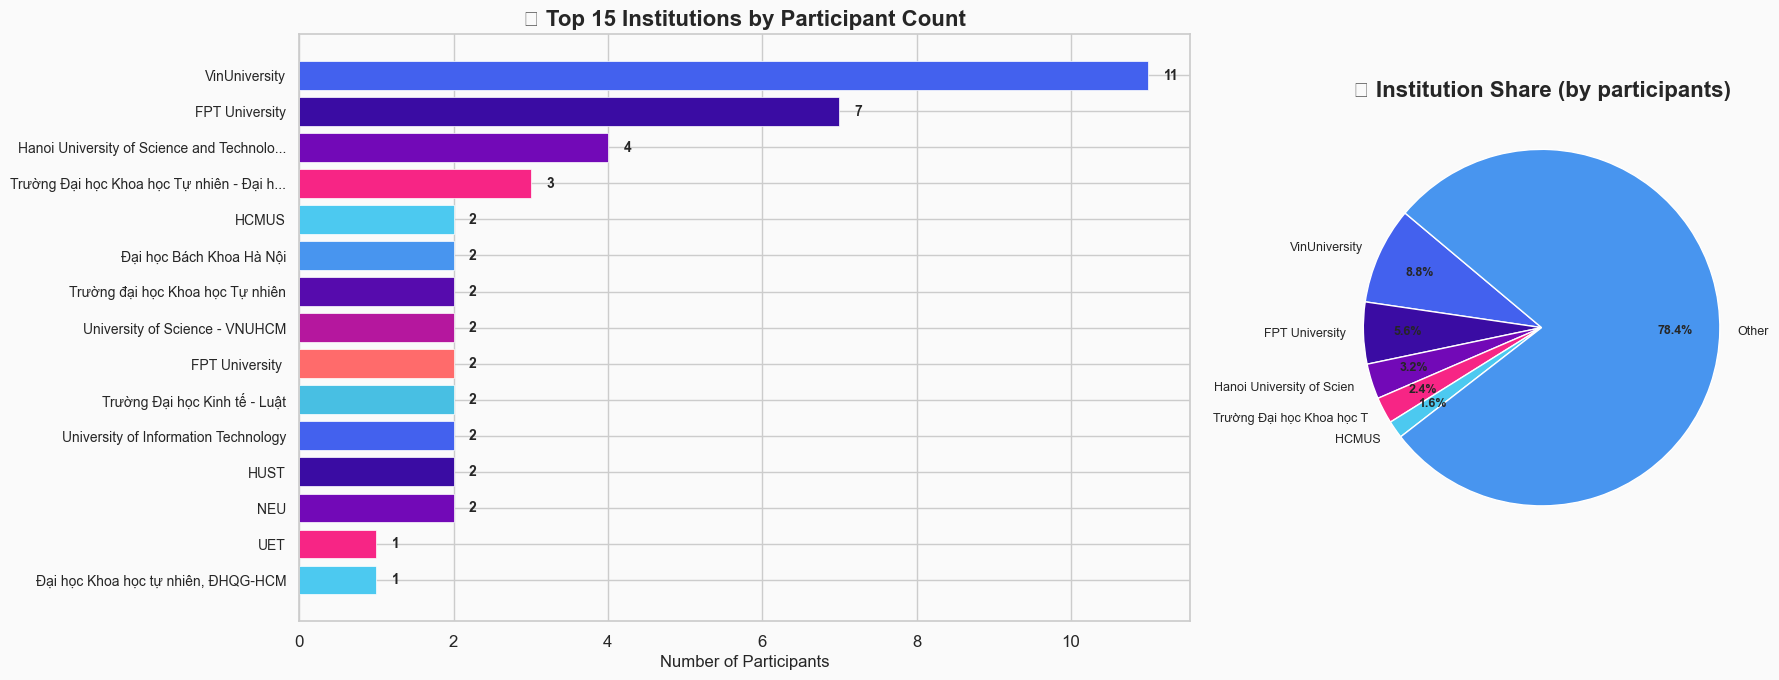

In [78]:
# ── Top Institutions Bar Chart (MEMBER-level university) ──────
# inst_counts was already computed from members_df['university'] in Section 2
top_n = min(15, len(inst_counts))
top_inst = inst_counts.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={'width_ratios': [2, 1]})

# Horizontal bar chart
colors = [PALETTE[i % len(PALETTE)] for i in range(top_n)]
bars = axes[0].barh(range(top_n), top_inst.values[::-1], color=colors[::-1], edgecolor='white', linewidth=0.5)
axes[0].set_yticks(range(top_n))
# Truncate long names
labels = [name[:40] + '...' if len(str(name)) > 40 else str(name) for name in top_inst.index[::-1]]
axes[0].set_yticklabels(labels, fontsize=10)
axes[0].set_xlabel('Number of Participants')
axes[0].set_title(f'🏫 Top {top_n} Institutions by Participant Count')

for bar, val in zip(bars, top_inst.values[::-1]):
    axes[0].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val}', va='center', fontsize=10, fontweight='bold')

# Pie chart: top 5 + Other
top5 = inst_counts.head(5)
other = inst_counts.iloc[5:].sum() if len(inst_counts) > 5 else 0
pie_data = list(top5.values)
pie_labels = [str(n)[:25] for n in top5.index]
if other > 0:
    pie_data.append(other)
    pie_labels.append('Other')

wedges, texts, autotexts = axes[1].pie(
    pie_data, labels=pie_labels, autopct='%1.1f%%',
    colors=PALETTE[:len(pie_data)], startangle=140,
    pctdistance=0.75, textprops={'fontsize': 9}
)
for autotext in autotexts:
    autotext.set_fontweight('bold')
axes[1].set_title('🎯 Institution Share (by participants)')

fig.tight_layout()
plt.show()

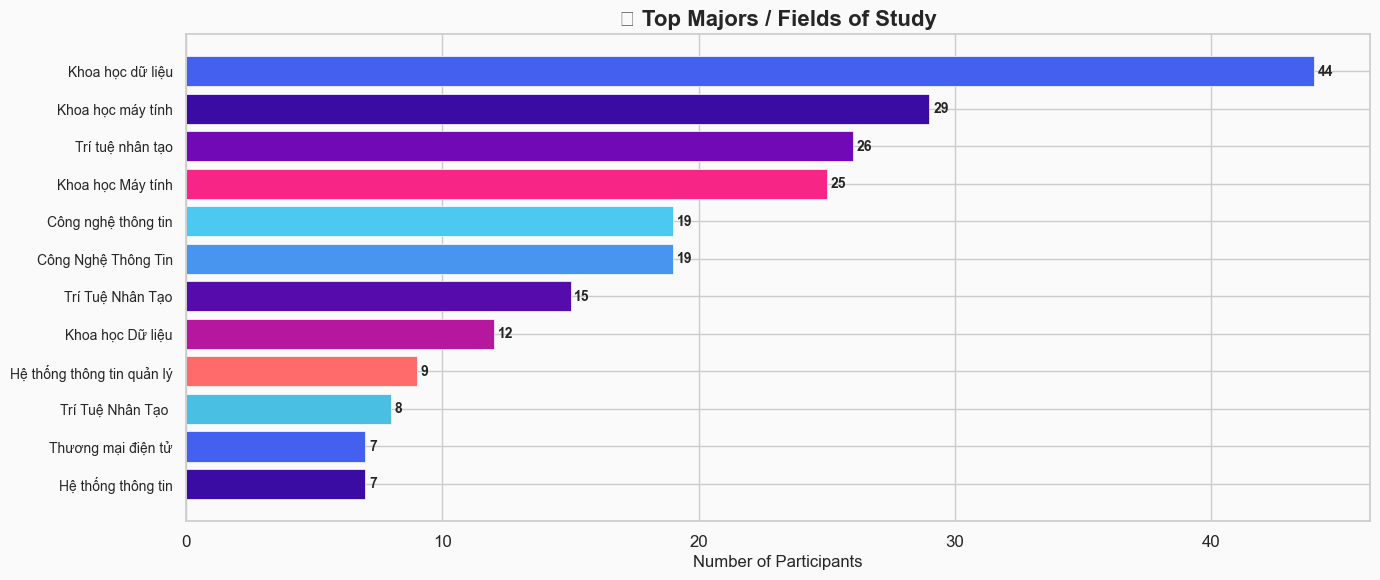

In [79]:
# ── Major / Field Distribution ────────────────────────────────
if len(members_df) > 0 and 'major' in members_df.columns:
    major_counts = members_df['major'].dropna().value_counts()
    top_majors = major_counts.head(12)

    fig, ax = plt.subplots(figsize=(14, 6))
    bars = ax.barh(range(len(top_majors)), top_majors.values[::-1],
                   color=[PALETTE[i % len(PALETTE)] for i in range(len(top_majors))][::-1],
                   edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(top_majors)))
    labels = [str(m)[:45] + '...' if len(str(m)) > 45 else str(m) for m in top_majors.index[::-1]]
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel('Number of Participants')
    ax.set_title('📚 Top Majors / Fields of Study')

    for bar, val in zip(bars, top_majors.values[::-1]):
        ax.text(val + 0.15, bar.get_y() + bar.get_height()/2,
                f'{val}', va='center', fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("ℹ️  No 'major' column found in member data.")

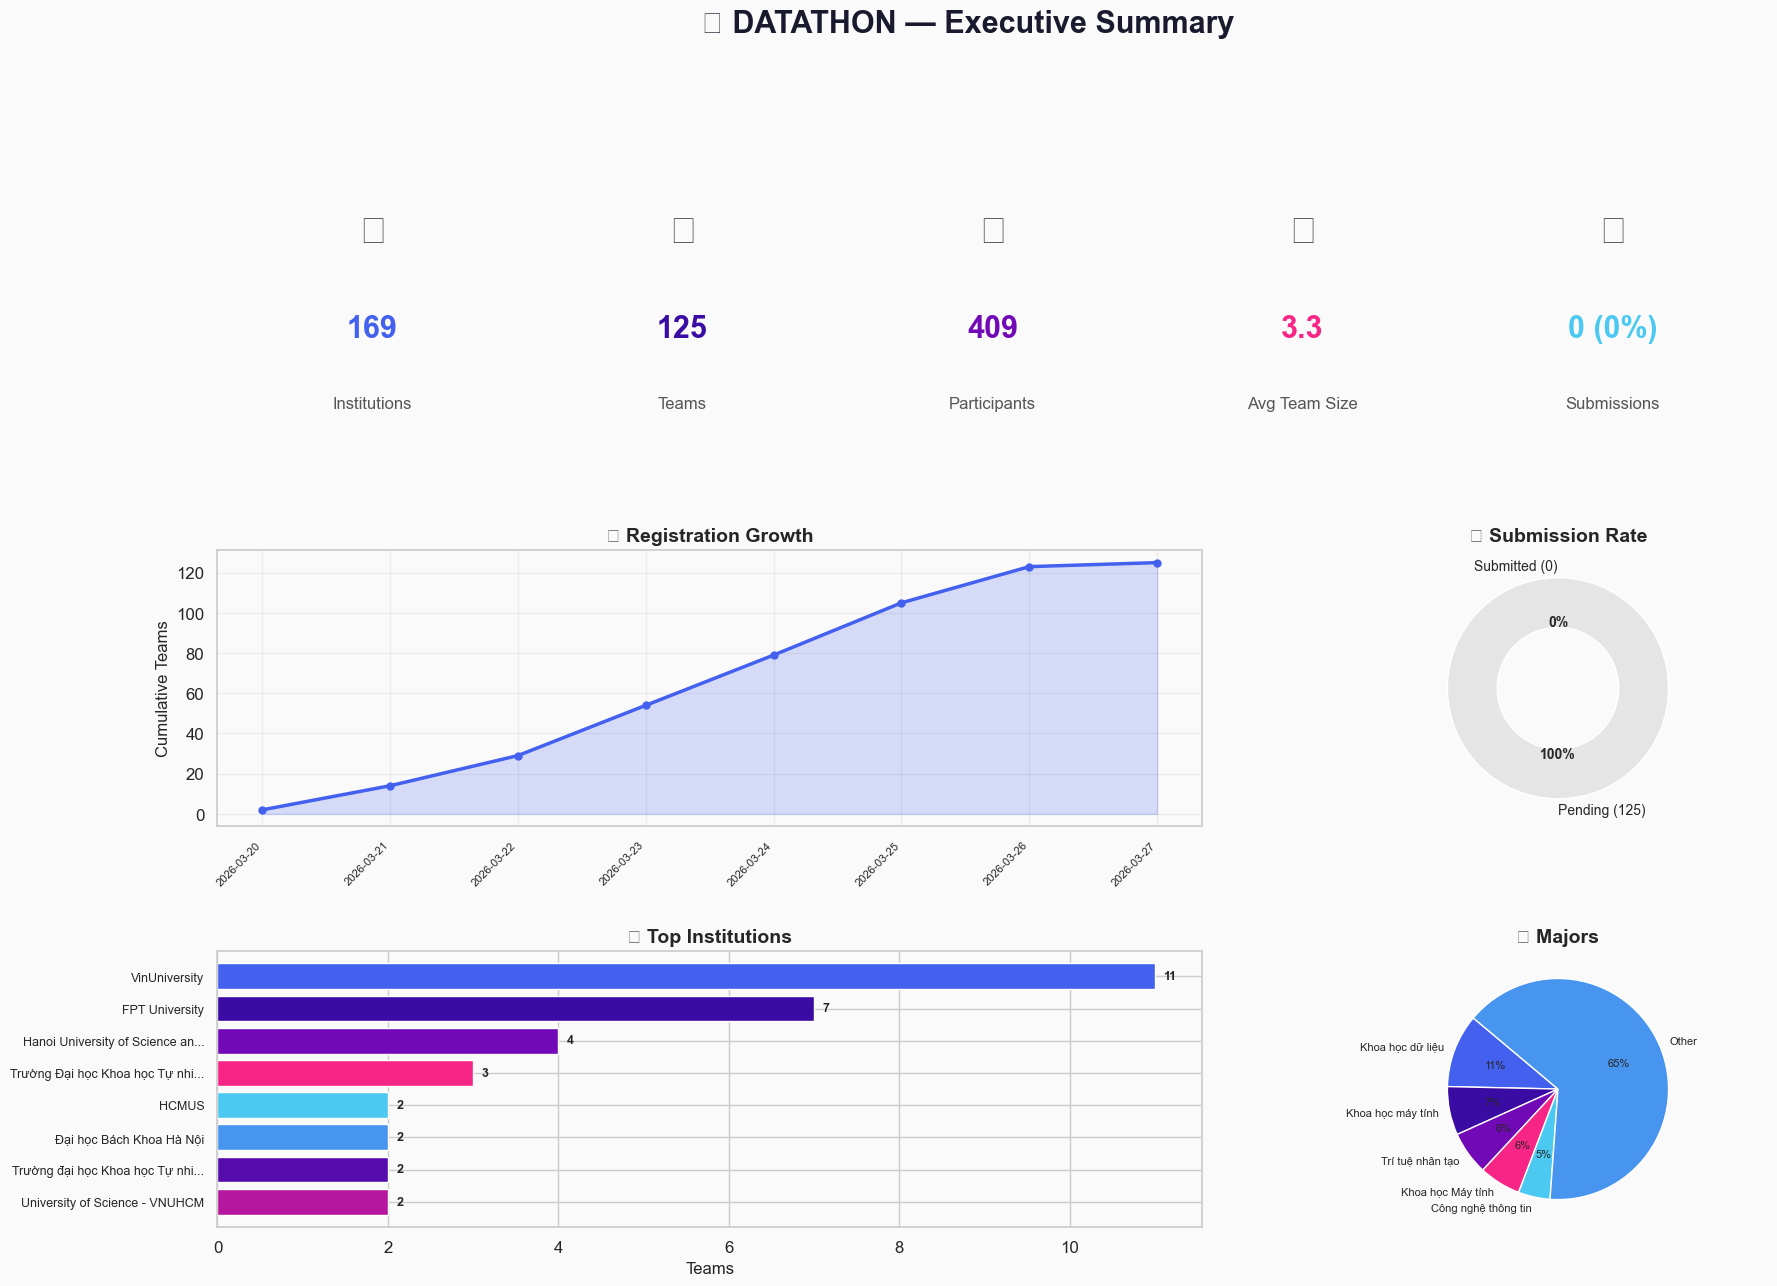

💾 Dashboard saved as datathon_dashboard.png


In [80]:
# ── All-in-one dashboard ──────────────────────────────────────
fig = plt.figure(figsize=(20, 14), facecolor='#FAFAFA')
fig.suptitle('🏆 DATATHON — Executive Summary',
             fontsize=22, fontweight='bold', y=0.98, color='#1A1A2E')

# Create grid
gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# ── KPI Cards (top row, spanning all 3 columns) ─────────────
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.axis('off')

kpis = [
    ('🏫', 'Institutions', str(unique_institutions)),
    ('👥', 'Teams', str(total_teams)),
    ('🧑', 'Participants', str(total_participants)),
    ('📐', 'Avg Team Size', f'{avg_team_size:.1f}'),
]
if submitted != 'N/A':
    kpis.append(('📝', 'Submissions', f'{submitted} ({submission_rate:.0f}%)'))

n_kpis = len(kpis)
for i, (icon, label, value) in enumerate(kpis):
    x = (i + 0.5) / n_kpis
    ax_kpi.text(x, 0.70, icon, fontsize=28, ha='center', va='center',
                transform=ax_kpi.transAxes)
    ax_kpi.text(x, 0.35, value, fontsize=22, ha='center', va='center',
                fontweight='bold', color=PALETTE[i % len(PALETTE)],
                transform=ax_kpi.transAxes)
    ax_kpi.text(x, 0.08, label, fontsize=12, ha='center', va='center',
                color='#555', transform=ax_kpi.transAxes)

# ── Registration Trend (middle-left) ─────────────────────────
ax_reg = fig.add_subplot(gs[1, 0:2])
if len(reg_by_date) > 0:
    ax_reg.fill_between(range(len(reg_by_date)), reg_by_date['cumulative'],
                        alpha=0.2, color=PALETTE[0])
    ax_reg.plot(range(len(reg_by_date)), reg_by_date['cumulative'],
                color=PALETTE[0], linewidth=2.5, marker='o', markersize=5)
    ax_reg.set_xticks(range(len(reg_by_date)))
    ax_reg.set_xticklabels([str(d) for d in reg_by_date['reg_date']], rotation=45, ha='right', fontsize=8)
    ax_reg.set_ylabel('Cumulative Teams')
    ax_reg.set_title('📅 Registration Growth', fontsize=14)
    ax_reg.grid(alpha=0.3)

# ── Submission Donut (middle-right) ──────────────────────────
ax_sub = fig.add_subplot(gs[1, 2])
if 'round1Submission' in df.columns:
    sub = df['round1Submission'].notna().sum()
    not_sub = df['round1Submission'].isna().sum()
    wedges, texts, autotexts = ax_sub.pie(
        [sub, not_sub],
        labels=[f'Submitted ({sub})', f'Pending ({not_sub})'],
        autopct='%1.0f%%',
        colors=[PALETTE[0], '#E5E5E5'],
        startangle=90,
        wedgeprops=dict(width=0.45, edgecolor='white'),
        textprops={'fontsize': 10}
    )
    for at in autotexts:
        at.set_fontweight('bold')
    ax_sub.set_title('📝 Submission Rate', fontsize=14)
else:
    ax_sub.text(0.5, 0.5, 'N/A', ha='center', va='center', fontsize=16)
    ax_sub.set_title('📝 Submission Rate', fontsize=14)

# ── Top Institutions (bottom-left) ────────────────────────────
ax_inst = fig.add_subplot(gs[2, 0:2])
top8 = inst_counts.head(8)
bars = ax_inst.barh(range(len(top8)), top8.values[::-1],
                    color=[PALETTE[i % len(PALETTE)] for i in range(len(top8))][::-1],
                    edgecolor='white')
ax_inst.set_yticks(range(len(top8)))
trunc_labels = [str(n)[:30] + '...' if len(str(n)) > 30 else str(n) for n in top8.index[::-1]]
ax_inst.set_yticklabels(trunc_labels, fontsize=9)
ax_inst.set_xlabel('Teams')
ax_inst.set_title('🏫 Top Institutions', fontsize=14)
for bar, val in zip(bars, top8.values[::-1]):
    ax_inst.text(val + 0.1, bar.get_y() + bar.get_height()/2,
                 str(val), va='center', fontsize=9, fontweight='bold')

# ── Major Distribution (bottom-right) ────────────────────────
ax_major = fig.add_subplot(gs[2, 2])
if len(members_df) > 0 and 'major' in members_df.columns:
    top5_majors = members_df['major'].dropna().value_counts().head(5)
    other_m = members_df['major'].dropna().value_counts().iloc[5:].sum() if len(members_df['major'].dropna().value_counts()) > 5 else 0
    m_data = list(top5_majors.values)
    m_labels = [str(m)[:20] for m in top5_majors.index]
    if other_m > 0:
        m_data.append(other_m)
        m_labels.append('Other')
    ax_major.pie(m_data, labels=m_labels, autopct='%1.0f%%',
                 colors=PALETTE[:len(m_data)], startangle=140,
                 textprops={'fontsize': 8})
    ax_major.set_title('📚 Majors', fontsize=14)
else:
    ax_major.text(0.5, 0.5, 'N/A', ha='center', va='center', fontsize=16)
    ax_major.set_title('📚 Majors', fontsize=14)

plt.savefig('datathon_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print("💾 Dashboard saved as datathon_dashboard.png")